# Off-target & rRNA features flag *bad* ASOs

Hypothesis: ASOs that carry **off-target burden — especially complementarity to ribosomal RNA**
— are rarely effective (sequestered / mis-targeted). These features don't pick the winners, but
they reliably flag losers (a negative filter).

Everything is measured **within cohort** (`custom_id`, which nests cell line and is essentially
single-chemistry), because Inhibition(%) is not comparable across experiments. Features are
oriented so **higher = more off-target burden**. Helpers in `_feat.py`; data is the full set
(all 131k oligos), cached to `data/raw_offtarget.parquet`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _feat as f
f.setup_style()
df = f.load()
print('oligos:', len(df), '| cohorts:', df[f.COHORT].nunique(), '| cell lines:', df.Cell_line.nunique())

oligos: 131711 | cohorts: 1701 | cell lines: 35


## 1 · Dose-response: more off-target burden → lower within-cohort efficacy
Bars are mean within-cohort residual inhibition (oligo minus its cohort mean); error bars = SE.

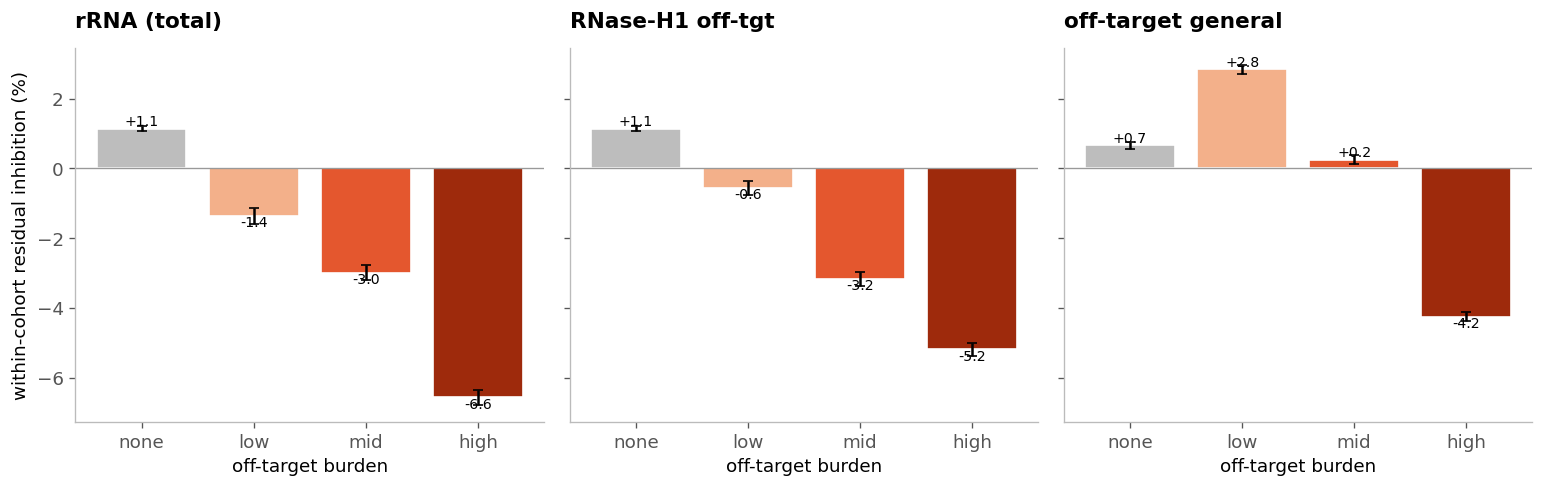

In [2]:
feats = ['rRNA (total)', 'RNase-H1 off-tgt', 'off-target general']
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for a, name in zip(ax, feats):
    t = f.resid_by_bin(df, name)
    a.bar(range(len(t)), t['mean'], yerr=t['se'], color=f.SEQ[:len(t)], capsize=3, edgecolor='white')
    a.set_xticks(range(len(t))); a.set_xticklabels(t.index)
    a.axhline(0, color='#999', lw=.8); a.set_title(name); a.set_xlabel('off-target burden')
    for i, (m, n) in enumerate(zip(t['mean'], t['n'])):
        a.annotate(f'{m:+.1f}', (i, m), ha='center', va='bottom' if m >= 0 else 'top', fontsize=8.5)
ax[0].set_ylabel('within-cohort residual inhibition (%)')
plt.tight_layout(); plt.show()

## 2 · Strong ASOs are depleted of off-target hits
Within each cohort, label the top-25%-inhibition oligos *strong* and bottom-25% *weak*; bars show the fraction carrying any of that off-target burden.

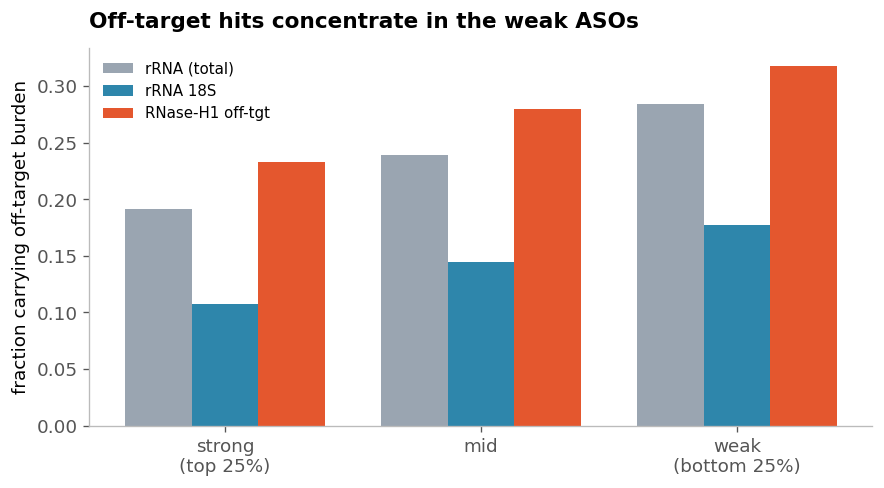

In [3]:
cats = ['strong', 'mid', 'weak']; feats = ['rRNA (total)', 'rRNA 18S', 'RNase-H1 off-tgt']
x = np.arange(len(cats)); w = 0.26
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for i, name in enumerate(feats):
    d = f.strong_weak_depletion(df, name)
    ax.bar(x + (i-1)*w, [d[c] for c in cats], w, label=name, color=[f.GREY, f.BLUE, f.ACCENT][i])
ax.set_xticks(x); ax.set_xticklabels(['strong\n(top 25%)', 'mid', 'weak\n(bottom 25%)'])
ax.set_ylabel('fraction carrying off-target burden'); ax.set_title('Off-target hits concentrate in the weak ASOs')
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

## 3 · Consistent *within* cohorts — not a cross-experiment artifact
Distribution over cohorts of Spearman(burden, inhibition). Centred left of 0 = burden flags worse ASOs in most experiments.

/tmp/claude-1000/ipykernel_2215858/3100153284.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=feats, showmeans=True, patch_artist=True,


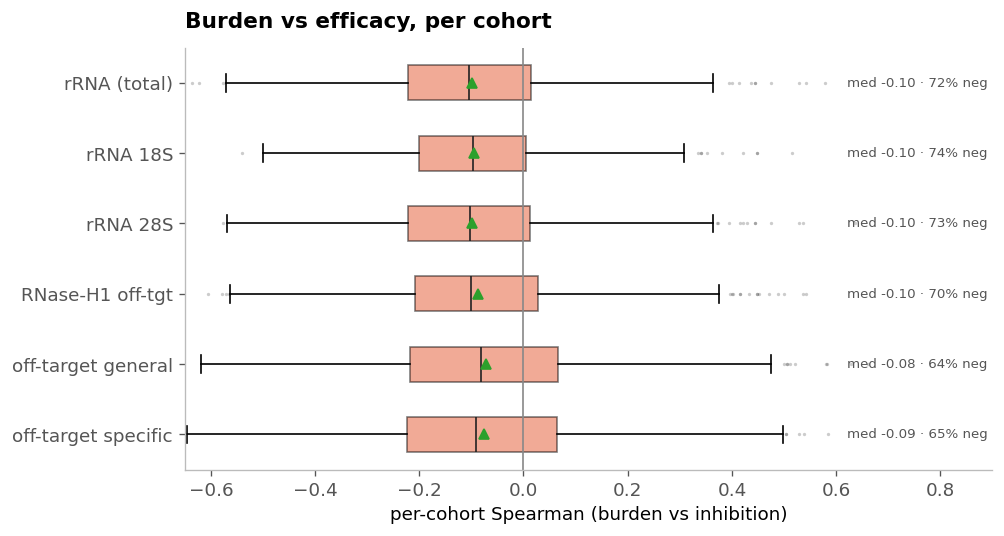

In [4]:
feats = list(f.BURDEN)
data = [f.per_cohort_corr(df, n) for n in feats]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
bp = ax.boxplot(data, vert=False, labels=feats, showmeans=True, patch_artist=True,
                medianprops=dict(color='#222'), flierprops=dict(marker='.', ms=2, alpha=.2))
for b in bp['boxes']: b.set_facecolor(f.ACCENT); b.set_alpha(.5)
ax.axvline(0, color='#888', lw=1)
for i, d in enumerate(data):
    ax.text(0.62, i+1, f'med {np.median(d):+.2f} · {100*np.mean(d<0):.0f}% neg', va='center', fontsize=8, color='#555')
ax.set_xlim(-0.65, 0.9); ax.invert_yaxis(); ax.set_xlabel('per-cohort Spearman (burden vs inhibition)')
ax.set_title('Burden vs efficacy, per cohort'); plt.tight_layout(); plt.show()

## 4 · Holds across chemistry & cell line
The rRNA effect is present in both chemistries (stronger in cEt) and across the major cell lines.

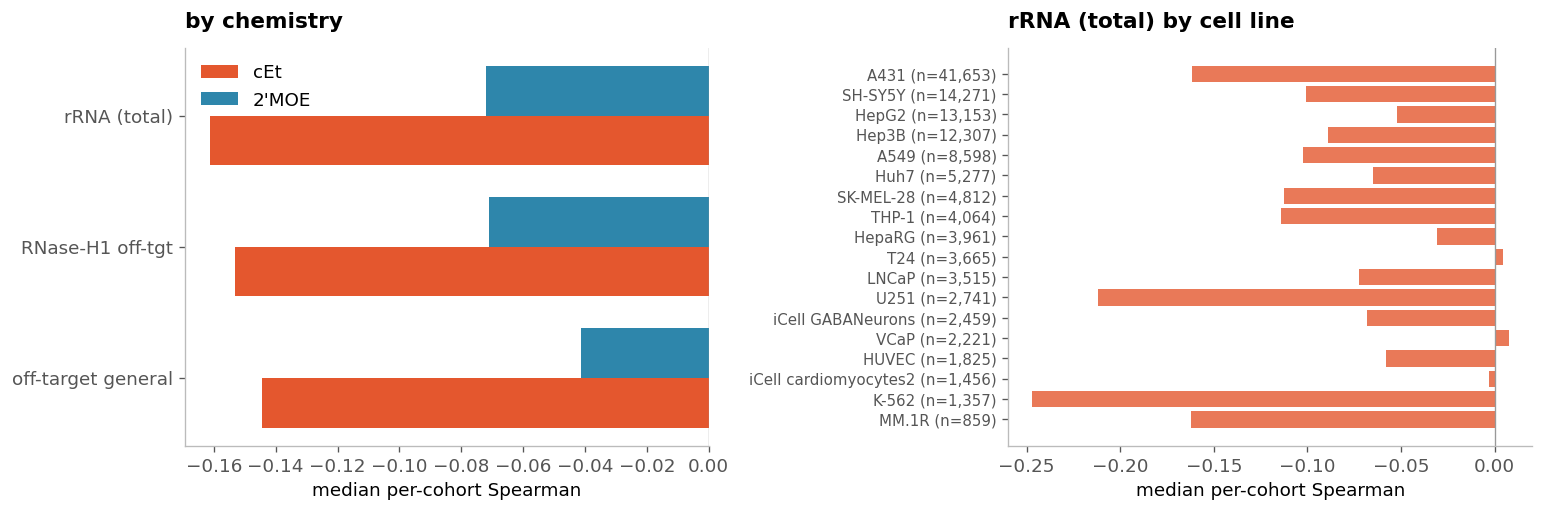

In [5]:
name = 'rRNA (total)'
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
# by chemistry, two features
chems = ['cEt', "2'MOE"]; show = ['rRNA (total)', 'RNase-H1 off-tgt', 'off-target general']
xx = np.arange(len(show)); w = 0.38
for j, ch in enumerate(chems):
    sub = df[df.chem == ch]
    meds = [np.median(f.per_cohort_corr(sub, s)) for s in show]
    ax[0].barh(xx + (0.5-j)*w, meds, w, label=ch, color=[f.ACCENT, f.BLUE][j])
ax[0].set_yticks(xx); ax[0].set_yticklabels(show); ax[0].invert_yaxis(); ax[0].axvline(0, color='#999', lw=.8)
ax[0].set_xlabel('median per-cohort Spearman'); ax[0].set_title('by chemistry'); ax[0].legend(frameon=False)
# by cell line (rRNA total), sorted by n
nc = df.groupby('Cell_line').size().sort_values(ascending=False)
cl = [c for c in nc.index if (df.Cell_line == c).sum() >= 800]
meds = [(c, np.median(f.per_cohort_corr(df[df.Cell_line == c], name)), int((df.Cell_line == c).sum())) for c in cl]
meds = [m for m in meds if np.isfinite(m[1])]
y = np.arange(len(meds))[::-1]
ax[1].barh(y, [m[1] for m in meds], color=f.ACCENT, alpha=.8)
ax[1].set_yticks(y); ax[1].set_yticklabels([f'{m[0]} (n={m[2]:,})' for m in meds], fontsize=9)
ax[1].axvline(0, color='#999', lw=.8); ax[1].set_xlabel('median per-cohort Spearman')
ax[1].set_title(f'{name} by cell line'); plt.tight_layout(); plt.show()